In [1]:
import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# import t-SNE
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


class CHIMEFRBDataset(Dataset):
    def __init__(self, hdf5_path, catalog_path, target_length):
        self.hdf5_path = hdf5_path
        self.dt = 0.009830400085775182 * 1000
        self._h5 = None

        self.target_length = target_length
        cat = pd.read_csv(catalog_path, low_memory=False)
        cat["repeater_name"] = cat["repeater_name"].fillna("").str.strip()
        self.repeater_set = set(
            cat.loc[cat["repeater_name"] != "", "tns_name"].str.strip()
        )
        with h5py.File(hdf5_path, "r") as f:
            self.keys = list(f.keys())

        # Precompute labels directly from the catalog/keys -- avoids reading
        # every waterfall from disk just to build the stratification labels.
        self.labels = np.array([int(k in self.repeater_set) for k in self.keys], dtype=np.int64)

    @staticmethod
    def _pad_or_crop(wfall, target_length, center_idx):
        n_freq, n_time = wfall.shape
        half = target_length // 2
        start = center_idx - half
        end = start + target_length

        if start >= 0 and end <= n_time:
            return wfall[:, start:end]

        src_start = max(start, 0)
        src_end = min(end, n_time)
        out = np.zeros((n_freq, target_length), dtype=wfall.dtype)
        dst_start = src_start - start
        out[:, dst_start:dst_start + (src_end - src_start)] = wfall[:, src_start:src_end]
        return out

    def _get_file(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.hdf5_path, "r")
        return self._h5

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        key = self.keys[idx]

        f = self._get_file()
        wfall = f[key]["wfall_plot"][:]
        extent = np.array(f[key]["extent"])

        wfall = wfall.astype(np.float32)
        std = wfall.std(axis=1, keepdims=True)
        std[std == 0] = 1.0  # avoid divide-by-zero for masked channels
        wfall = (wfall - wfall.mean(axis=1, keepdims=True)) / std

        peak = round(-extent[0] / self.dt)
        wfall = self._pad_or_crop(wfall, self.target_length, peak)
        tensor = torch.from_numpy(wfall)
        label = torch.tensor(int(key in self.repeater_set), dtype=torch.long)

        return tensor, label


TARGET_LENGTH = 128
N_SPLITS = 5
BATCH_SIZE = 64
NUM_WORKERS = 5
SEED = 42



class WaterfallAugment(nn.Module):
    def __init__(self, time_mask_frac=0.15, freq_mask_frac=0.15, noise_std=0.05, crop_frac_range=(0.7, 1.0)):
        super().__init__()
        self.time_mask_frac = time_mask_frac
        self.freq_mask_frac = freq_mask_frac
        self.noise_std = noise_std
        self.crop_frac_range = crop_frac_range
        
    def _random_time_crop(self, x):
        # pads with zeroes (ref https://arxiv.org/pdf/2103.01929)
        B, n_freq, seq_len = x.shape
        out = torch.zeros_like(x)
        for i in range(B):
            frac = float(torch.empty(1).uniform_(*self.crop_frac_range))
            crop_len = min(seq_len, max(1, int(seq_len * frac))) # choose window size
            src_start = int(torch.randint(0, seq_len - crop_len + 1, (1,))) # choose where to start copying
            dst_start = int(torch.randint(0, seq_len - crop_len + 1, (1,))) # choose where to copy into
            out[i, :, dst_start:dst_start + crop_len] = x[i, :, src_start:src_start + crop_len]
        return out

    def forward(self, x):
        x = x.clone()
        x = self._random_time_crop(x)

        B, n_freq, seq_len = x.shape

        # Per-sample time masking
        t_mask = max(1, int(seq_len * self.time_mask_frac))
        for i in range(B):
            t0 = torch.randint(0, seq_len - t_mask, (1,)).item()
            x[i, :, t0 : t0 + t_mask] = 0.0

        # Per-sample frequency masking
        f_mask = max(1, int(n_freq * self.freq_mask_frac))
        for i in range(B):
            f0 = torch.randint(0, n_freq - f_mask, (1,)).item()
            x[i, f0 : f0 + f_mask, :] = 0.0

        # Gaussian noise (already per-sample since randn_like is elementwise)
        x = x + torch.randn_like(x) * self.noise_std

        return x


class SinusoidalPE(nn.Module):
    def __init__(self, seq_len, embed_dim):
        super().__init__()
        pe = torch.zeros(seq_len, embed_dim)
        pos = torch.arange(seq_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, embed_dim, 2) * (-np.log(10000) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe


class FRBMaskedAutoencoderConcat(nn.Module):
    def __init__(self, seq_len, n_freq, embed_dim, dec_embed_dim, contrast_dim=32, mask_ratio=0.25, dropout=0.1, n_enc_heads=4, n_dec_heads=2, dim_feedforward_enc=128, dim_feedforward_dec=128, n_enc_blocks=2, n_dec_blocks=2):
        super().__init__()
        self.seq_len = seq_len
        self.n_freq = n_freq
        self.embed_dim = embed_dim
        self.dec_embed_dim = dec_embed_dim
        self.contrast_dim = contrast_dim
        self.mask_ratio = mask_ratio

        self.enc_proj = nn.Linear(n_freq, embed_dim)
        self.enc_drop = nn.Dropout(dropout)
        self.enc_pe = SinusoidalPE(seq_len + 1, embed_dim)
        self.enc_blocks = nn.ModuleList([nn.TransformerEncoderLayer(embed_dim, 
                                                                    nhead=n_enc_heads, 
                                                                    dim_feedforward=dim_feedforward_enc, 
                                                                    batch_first=True, dropout=dropout) 
                                         for _ in range(n_enc_blocks)])
        self.enc_norm = nn.LayerNorm(embed_dim)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_embed_dim))

        self.enc_to_dec = nn.Linear(embed_dim, dec_embed_dim)
        self.dec_pe = SinusoidalPE(seq_len + 1, dec_embed_dim)
        self.dec_blocks = nn.ModuleList([nn.TransformerEncoderLayer(dec_embed_dim, 
                                                                    nhead=n_dec_heads, 
                                                                    dim_feedforward=dim_feedforward_dec, 
                                                                    batch_first=True, dropout=dropout) 
                                         for _ in range(n_dec_blocks)])
        self.dec_norm = nn.LayerNorm(dec_embed_dim)
        self.dec_proj = nn.Linear(dec_embed_dim, n_freq)

        self.cls_head = nn.Sequential(nn.Linear(embed_dim * 2, embed_dim), 
                                      nn.LayerNorm(embed_dim), 
                                      nn.ReLU(),
                                      nn.Dropout(dropout), 
                                      nn.Linear(embed_dim, embed_dim // 2), 
                                      nn.ReLU(), nn.Dropout(dropout), 
                                      nn.Linear(embed_dim // 2, 1))

        self.proj_head = nn.Sequential(nn.Linear(embed_dim, embed_dim), 
                                       nn.LayerNorm(embed_dim), 
                                       nn.ReLU(), 
                                       nn.Dropout(dropout), 
                                       nn.Linear(embed_dim, contrast_dim))

        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.mask_token, std=0.02)

        self.augment_fn = WaterfallAugment(time_mask_frac=0.15, freq_mask_frac=0.15, noise_std=0.05)

    def mask_input(self, x, shared_noise=None):
        B, F, T = x.shape
        len_keep = int(F * (1 - self.mask_ratio))

        if shared_noise is not None:
            noise = shared_noise
        else:
            noise = torch.rand(B, F, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, T))

        mask = torch.ones(B, F, device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore, ids_keep

    def encoder(self, x, shared_noise=None, mask_input=True):
        x = self.enc_drop(self.enc_proj(x))
        x = x + self.enc_pe.pe[1 : self.seq_len + 1]

        if mask_input:
            x_vis, mask, ids_restore, ids_keep = self.mask_input(x, shared_noise)
        else:
            x_vis = x
            mask = None
            ids_restore = None
            ids_keep = None

        cls = (self.cls_token + self.enc_pe.pe[0]).expand(x_vis.size(0), -1, -1)
        x_vis = torch.cat([cls, x_vis], dim=1)

        for block in self.enc_blocks:
            x_vis = block(x_vis)
        x_vis = self.enc_norm(x_vis)

        return x_vis, mask, ids_restore

    def decoder(self, x_enc, ids_restore):
        B = x_enc.size(0)
        T = ids_restore.size(1)
        n_keep = x_enc.size(1) - 1
        mask_tokens = self.mask_token.expand(B, T - n_keep, -1)

        x_enc = self.enc_to_dec(x_enc)

        x_no_cls = x_enc[:, 1:, :]
        x_full = torch.cat([x_no_cls, mask_tokens], dim=1)
        x_full = torch.gather(x_full, dim=1, index=ids_restore.unsqueeze(-1).expand(-1, -1, self.dec_embed_dim))

        x_full = x_full + self.dec_pe.pe[1 : T + 1]
        cls = x_enc[:, :1, :] + self.dec_pe.pe[0]
        x_full = torch.cat([cls, x_full], dim=1)

        for block in self.dec_blocks:
            x_full = block(x_full)
        x_full = self.dec_norm(x_full)

        recon = self.dec_proj(x_full[:, 1:, :])
        return recon

    def forward_pretrain(self, x, augment=True):
        x_t = x
        shared_noise = torch.rand(x_t.size(0), self.seq_len, device=x_t.device)
        x_enc, mask, ids_restore = self.encoder(x_t, shared_noise)
        cls_token = x_enc[:, 0, :] # 
        seq_tokens = x_enc[:, 1:, :]
        
        # pass cls token and every seq_token through the projection head for contrastive learning
        seq_token_emb = self.proj_head(seq_tokens)
        cls_token_emb = self.proj_head(cls_token)
        # concat every sequence token to the cls token to make one giant embedding for contrastive learning
        rich_embed = torch.cat([cls_token_emb, seq_token_emb.view(seq_token_emb.size(0), -1)], dim=1)
        proj1 = nn.functional.normalize(rich_embed, dim=1)
        recon = self.decoder(x_enc, ids_restore)

        if augment:
            x_aug = self.augment_fn(x)
            x_enc2, _, _ = self.encoder(x_aug, shared_noise)
            cls_token2 = x_enc2[:, 0, :]
            seq_tokens2 = x_enc2[:, 1:, :]
            seq_token_emb2 = self.proj_head(seq_tokens2)
            cls_token_emb2 = self.proj_head(cls_token2)
            rich_embed2 = torch.cat([cls_token_emb2, seq_token_emb2.view(seq_token_emb2.size(0), -1)], dim=1)
            proj2 = nn.functional.normalize(rich_embed2, dim=1)
            proj = torch.stack([proj1, proj2], dim=1)  # [B, 2, contrast_dim]
        else:
            proj = proj1.unsqueeze(1)  # fallback: [B, 1, contrast_dim]

        return recon, mask, proj

    def forward_finetune(self, x):
        x_t = x  # frequency channels are the token dimension
        shared_noise = torch.rand(x_t.size(0), self.seq_len, device=x_t.device)

        x_enc, _, _ = self.encoder(x_t, shared_noise, mask_input=False)

        cls_token = x_enc[:, 0, :]
        seq_tokens = x_enc[:, 1:, :]
        mean_pooled = seq_tokens.mean(dim=1)

        rich_embed = torch.cat([cls_token, mean_pooled], dim=1)

        cls_out = self.cls_head(rich_embed)

        return cls_out.squeeze(-1)


TARGET_LENGTH = 128
BATCH_SIZE = 64
NUM_WORKERS = 5
FOLD_IDX = 1 
 
HDF5_PATH = "/scratch/gpfs/MLISANTI/ra0438/all_bursts.hdf5"
CATALOG_PATH = "/home/ra0438/chime-catalog-two-analysis/chimefrbcat2.csv"

CHECKPOINT_DIR = "/scratch/gpfs/MLISANTI/ra0438/cmae_checkpoints_freq_concat"
OUTPUT_DIR = "/scratch/gpfs/MLISANTI/ra0438/cmae_checkpoints_freq_concat/cls_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
 
def build_model():
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"fold_{FOLD_IDX}.pt")
    ckpt = torch.load(ckpt_path, map_location=device)
    p = ckpt["params"]
    embed_dim = p["embed_dim"]
    dec_emb_dim = int(embed_dim * p["dec_emb_frac"])
    n_enc_heads = p["n_enc_heads"]
    n_dec_heads = max(1, int(n_enc_heads * p["n_dec_frac"]))
    dim_feedforward_enc = p["dim_feedforward"]
    dim_feedforward_dec = int(dim_feedforward_enc * p["dim_feedforward_dec_frac"])
    n_enc_blocks = p["n_enc_blocks"]
    n_dec_blocks = max(1, int(n_enc_blocks * p["n_dec_block_frac"]))
 
    model = FRBMaskedAutoencoderConcat(
        n_freq=TARGET_LENGTH,
        seq_len=256,
        embed_dim=embed_dim,
        dec_embed_dim=dec_emb_dim,
        contrast_dim=p["contrast_dim"],
        mask_ratio=p["mask_ratio"],
        dropout=p["dropout"],
        n_enc_heads=n_enc_heads,
        n_dec_heads=n_dec_heads,
        dim_feedforward_enc=dim_feedforward_enc,
        dim_feedforward_dec=dim_feedforward_dec,
        n_enc_blocks=n_enc_blocks,
        n_dec_blocks=n_dec_blocks,
    ).to(device)
    return model

cuda
NVIDIA A100 80GB PCIe MIG 1g.10gb


In [2]:
dataset = CHIMEFRBDataset(HDF5_PATH, CATALOG_PATH, TARGET_LENGTH)
n_total = len(dataset)
n_rep = int(dataset.labels.sum())
print(f"Dataset: {n_total} | repeaters: {n_rep} ({100 * n_rep / n_total:.1f}%)")

model = build_model()
ckpt_path = os.path.join(CHECKPOINT_DIR, f"fold_{FOLD_IDX}.pt")
print(f"Loading checkpoint: {ckpt_path}")
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

Dataset: 4536 | repeaters: 981 (21.6%)
Loading checkpoint: /scratch/gpfs/MLISANTI/ra0438/cmae_checkpoints_freq_concat/fold_1.pt


/tmp/ipykernel_1935740/1825273406.py:330: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)
/tmp/ipykernel_1935740/1386594247.p

In [3]:
def get_model_size_and_params(model):
    # Total number of parameters
    total_params = sum(p.numel() for p in model.parameters())
    

    # Each parameter is a float32 (4 bytes)
    total_size_bytes = total_params * 4
    total_size_mb = total_size_bytes / (1024 ** 2)  # Convert to MB
    
    print(f"Total parameters: {total_params:,}")
    print(f"Model size: {total_size_mb:.2f} MB")
    
get_model_size_and_params(model)

Total parameters: 340,865
Model size: 1.30 MB


In [4]:
def register_attention_hooks(model):
    attention_maps = {}
    handles = []

    def pre_hook(module, args, kwargs):
        kwargs["need_weights"] = True
        kwargs["average_attn_weights"] = False
        return args, kwargs

    def make_post_hook(name):
        def post_hook(module, input, output):
            # output = (attn_output, attn_weights) when need_weights=True
            _, attn_weights = output
            attention_maps[name] = attn_weights.detach().cpu()
        return post_hook

    for i, layer in enumerate(model.enc_blocks):
        handles.append(layer.self_attn.register_forward_pre_hook(pre_hook, with_kwargs=True))
        handles.append(layer.self_attn.register_forward_hook(make_post_hook(f"enc_{i}")))

    for i, layer in enumerate(model.dec_blocks):
        handles.append(layer.self_attn.register_forward_pre_hook(pre_hook, with_kwargs=True))
        handles.append(layer.self_attn.register_forward_hook(make_post_hook(f"dec_{i}")))

    return attention_maps, handles

In [5]:
model.eval()
attention_maps, handles = register_attention_hooks(model)

with torch.no_grad():
    wfall, labels = next(iter(loader))
    wfall = wfall.to(device)
    x_t = wfall  # [B, F, T]
    x_enc, _, _ = model.encoder(x_t, shared_noise=None, mask_input=False)

print({k: v.shape for k, v in attention_maps.items()})

{'enc_0': torch.Size([64, 1, 257, 257]), 'enc_1': torch.Size([64, 1, 257, 257]), 'enc_2': torch.Size([64, 1, 257, 257]), 'enc_3': torch.Size([64, 1, 257, 257])}


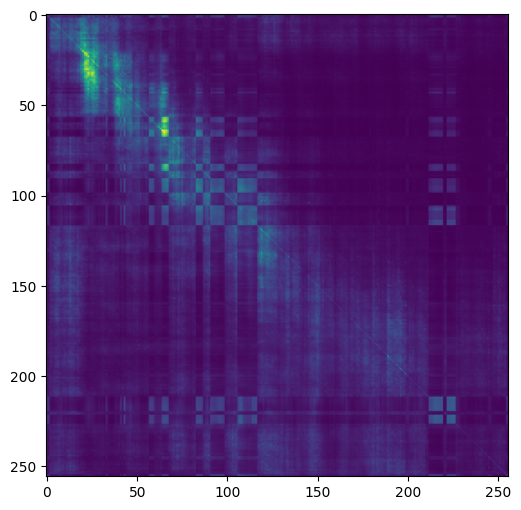

In [6]:
attn = attention_maps["enc_1"] # (B, n_heads, T+1, T+1)
attn_2d = attn.mean(dim=(0, 1)) # (T+1, T+1)

plt.figure(figsize=(10, 6))
plt.imshow(attn_2d[1:, 1:].numpy())


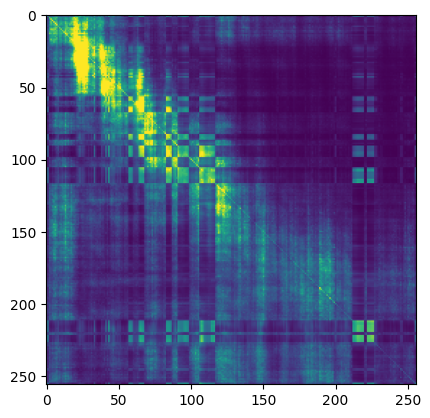

In [7]:
plt.imshow(attn_2d[1:, 1:].numpy(), vmax=np.percentile(attn_2d[1:,1:].numpy(), 99))

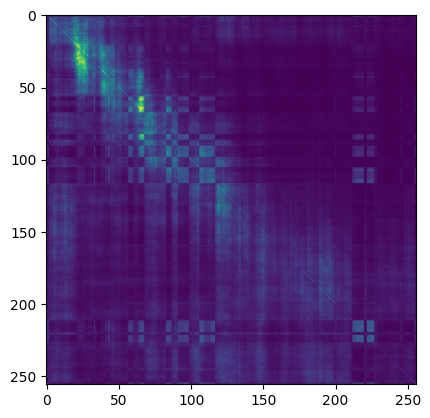

In [8]:
plt.imshow(np.log1p(attn_2d[1:,1:].numpy()))

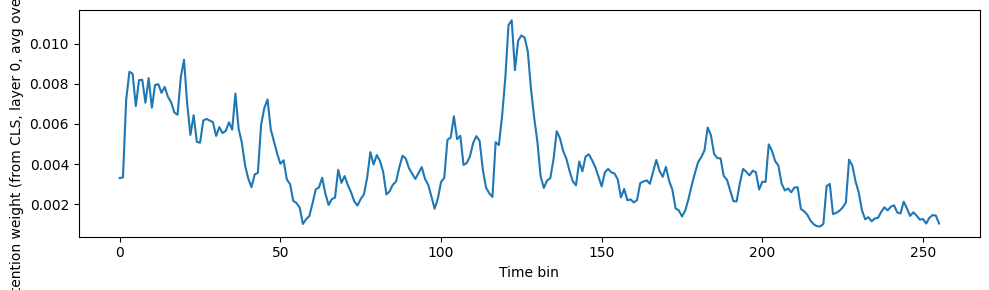

In [9]:
cls_attn_over_time = attn_2d[0, 1:]
plt.figure(figsize=(10, 3))
plt.plot(cls_attn_over_time.numpy())
plt.xlabel("Time bin")
plt.ylabel("Attention weight (from CLS, layer 0, avg over heads)")
plt.tight_layout()

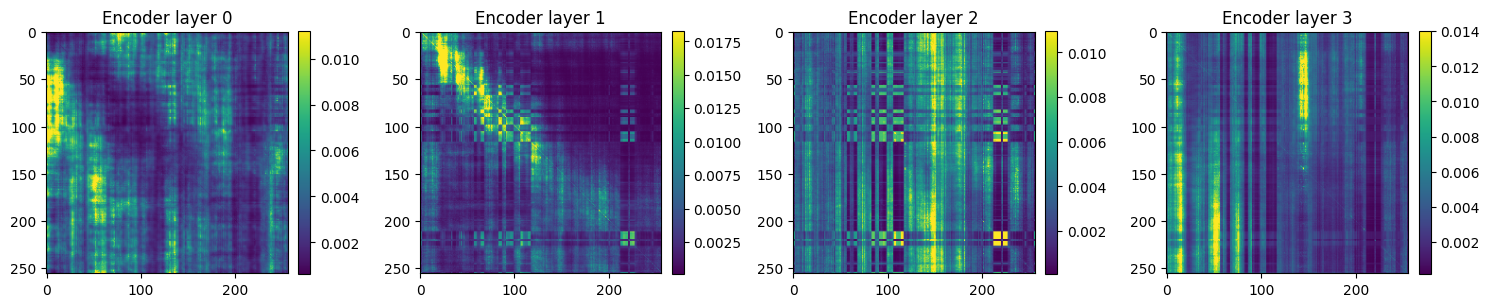

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 10))
axes = axes.flatten()

for enc_layer in range(4):
    attn_2d = attention_maps[f'enc_{enc_layer}'].mean(dim=(0, 1))[1:, 1:].numpy()

    im = axes[enc_layer].imshow(attn_2d, vmax=np.percentile(attn_2d, 99))
    axes[enc_layer].set_title(f"Encoder layer {enc_layer}")
    fig.colorbar(im, ax=axes[enc_layer], fraction=0.046, pad=0.04)

plt.tight_layout()

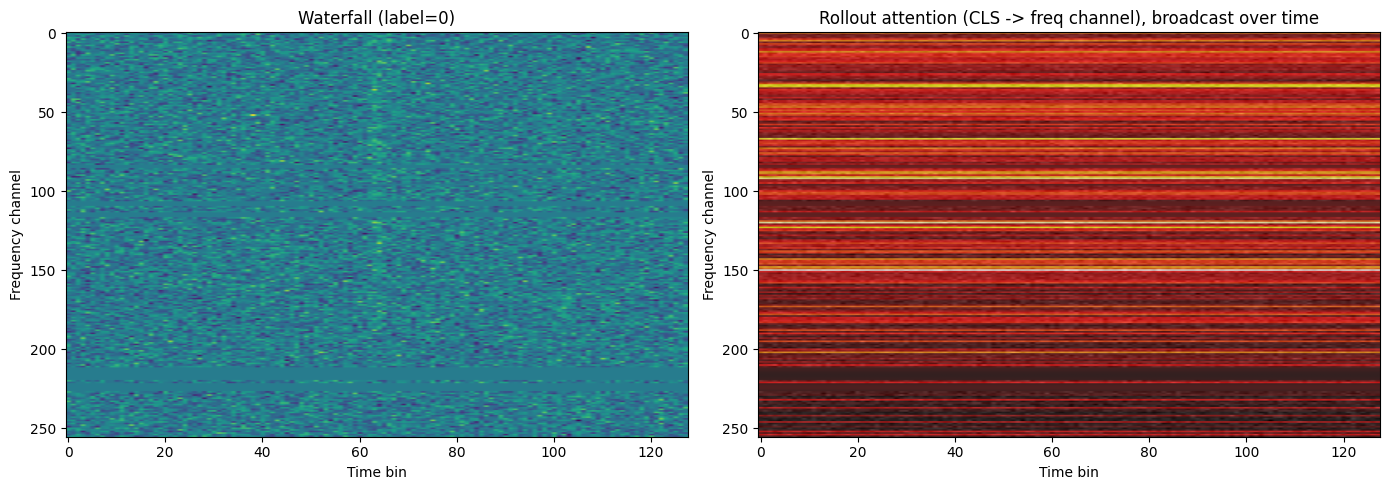

In [11]:
def get_ordered_encoder_attentions(attention_maps):
    enc_keys = sorted(
        [k for k in attention_maps if k.startswith("enc_")],
        key=lambda k: int(k.split("_")[1])
    )
    return [attention_maps[k] for k in enc_keys]

def attention_rollout(attentions):
    B, _, N, _ = attentions[0].shape
    rollout = torch.eye(N).unsqueeze(0).repeat(B, 1, 1)

    for attention in attentions:
        fused = attention.mean(dim=1)                              
        fused = fused + torch.eye(N).unsqueeze(0)                   
        fused = fused / fused.sum(dim=-1, keepdim=True)           
        rollout = torch.bmm(rollout, fused)               

    return rollout  # (B, N, N)

ordered_attns = get_ordered_encoder_attentions(attention_maps)
rollout = attention_rollout(ordered_attns)

sample_idx = 1
cls_attn = rollout[sample_idx, 0, 1:]          
cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8) #minmax scaling

wfall_sample = wfall[sample_idx].cpu().numpy()
attn_map_2d = cls_attn.numpy()[:, None] * np.ones((1, wfall_sample.shape[1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(wfall_sample, aspect="auto", cmap="viridis")
axes[0].set_title(f"Waterfall (label={labels[sample_idx].item()})")
axes[0].set_xlabel("Time bin")
axes[0].set_ylabel("Frequency channel")

axes[1].imshow(wfall_sample, aspect="auto", cmap="gray")
axes[1].imshow(attn_map_2d, aspect="auto", cmap="hot", alpha=0.7)
axes[1].set_title("Rollout attention (CLS -> freq channel), broadcast over time")
axes[1].set_xlabel("Time bin")
axes[1].set_ylabel("Frequency channel")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "attention_rollout_sample0.png"), dpi=150)
plt.show()

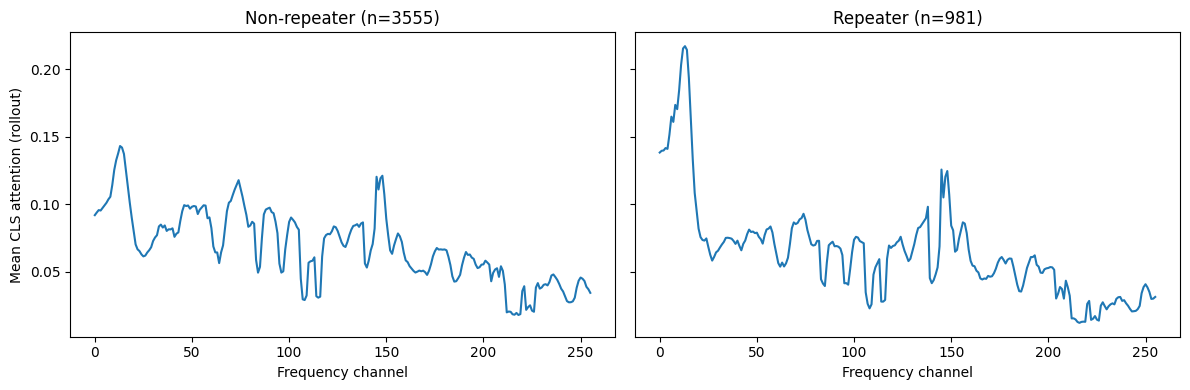

In [12]:
loader_full = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

sum_attn = {0: None, 1: None}
count = {0: 0, 1: 0}

model.eval()
with torch.no_grad():
    for wfall, labels in loader_full:
        wfall = wfall.to(device)
        attention_maps.clear()
        x_enc, _, _ = model.encoder(wfall, shared_noise=None, mask_input=False)

        ordered_attns = get_ordered_encoder_attentions(attention_maps)
        rollout = attention_rollout(ordered_attns)  # (B, N, N)

        cls_attn = rollout[:, 0, 1:]
        cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)

        for c in [0, 1]:
            mask = (labels == c)
            if mask.sum() == 0:
                continue
            batch_sum = cls_attn[mask].sum(dim=0)
            sum_attn[c] = batch_sum if sum_attn[c] is None else sum_attn[c] + batch_sum
            count[c] += mask.sum().item()

mean_attn = {c: (sum_attn[c] / count[c]).numpy() for c in [0, 1]}

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
titles = {0: "Non-repeater", 1: "Repeater"}

for c in [0, 1]:
    axes[c].plot(mean_attn[c])
    axes[c].set_title(f"{titles[c]} (n={count[c]})")
    axes[c].set_xlabel("Frequency channel")
axes[0].set_ylabel("Mean CLS attention (rollout)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_rollout_maps.png"), dpi=150)
plt.show()

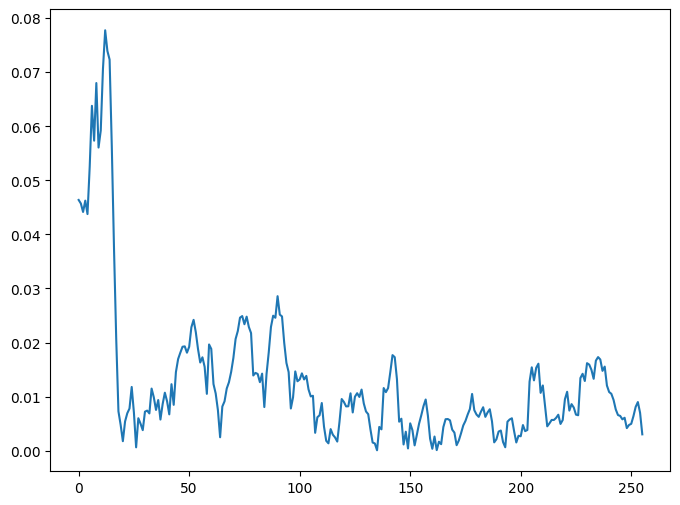

In [13]:
diff_attn = np.abs(mean_attn[1] - mean_attn[0])
plt.figure(figsize=(8, 6))
plt.plot(diff_attn)

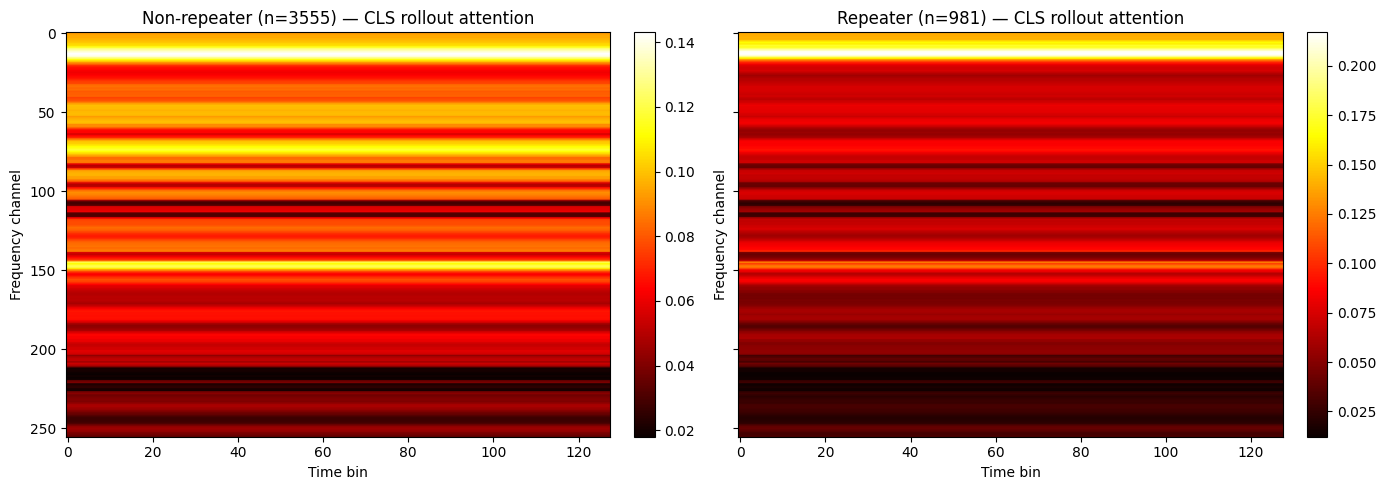

In [14]:
n_time = wfall.shape[-1]  # time bins, from last batch (all same TARGET_LENGTH)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
titles = {0: "Non-repeater", 1: "Repeater"}

for c in [0, 1]:
    attn_map_2d = mean_attn[c][:, None] * np.ones((1, n_time))
    im = axes[c].imshow(attn_map_2d, aspect="auto", cmap="hot")
    axes[c].set_title(f"{titles[c]} (n={count[c]}) — CLS rollout attention")
    axes[c].set_xlabel("Time bin")
    axes[c].set_ylabel("Frequency channel")
    fig.colorbar(im, ax=axes[c], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_rollout_heatmaps.png"), dpi=150)
plt.show()

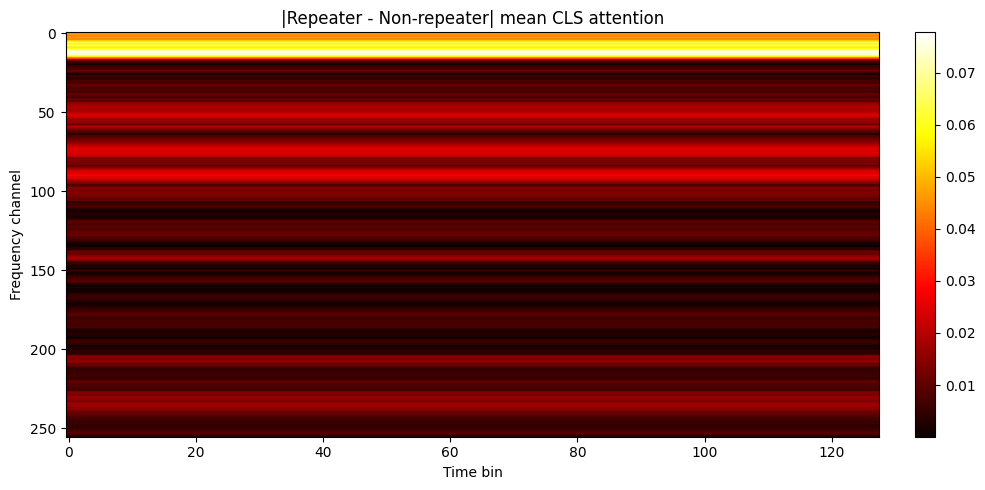

In [15]:
diff_map_2d = diff_attn[:, None] * np.ones((1, n_time))

plt.figure(figsize=(10, 5))
plt.imshow(diff_map_2d, aspect="auto", cmap="hot")
plt.title("|Repeater - Non-repeater| mean CLS attention")
plt.xlabel("Time bin")
plt.ylabel("Frequency channel")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_rollout_diff_heatmap.png"), dpi=150)
plt.show()